# Conway's Game of Life — Analysis Notebook

Phase 6 analysis of exported dashboard CSVs from `analysis/data/`.

**Pipeline:**
1. Load & validate CSVs (schema check, filename vs `run_id` match, duplicate drop)
2. Data quality summary
3. Exploratory plots
4. Distribution-free statistics (Spearman, bootstrap CI, Mann-Whitney)
5. Classification CV (Decision Tree, Logistic Regression, k-NN)
6. Regression CV (quadratic density → generations)


In [163]:
from pathlib import Path
import joblib, os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy import stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from datetime import datetime
from sklearn.model_selection import StratifiedKFold, KFold, cross_validate, cross_val_predict

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
warnings.simplefilter('default')  # keep warnings visible — suppressing hides model failures


## 1. Load & Validate CSVs

Checks performed per file:
- Required columns present
- `run_id` inside file matches filename stem
- Numeric coercion with NaN flagging
- `endReason` normalisation (lowercase, underscore)

After concat:
- Duplicate `(run_id, session)` pairs dropped (keep first)
- `densityBand` assigned — `edge_30_40` is the hypothesis zone


In [164]:
data_dir = Path('data')
files = sorted(data_dir.glob('*.csv'))

if not files:
    raise FileNotFoundError('No CSV files found in analysis/data/. Export from the dashboard first.')

required_columns = {
    'run_id', 'session', 'density', 'peakPop', 'avgEntropy',
    'avgPBirth', 'avgPDeath', 'generations', 'endReason', 'autocorr'
}
numeric_columns = ['session', 'density', 'peakPop', 'avgEntropy', 'avgPBirth', 'avgPDeath', 'generations', 'autocorr']
reason_map = {'stagnant': 0, 'died': 1, 'max_gens': 2}

frames = []
for path in files:
    frame = pd.read_csv(path)
    missing_columns = required_columns.difference(frame.columns)
    if missing_columns:
        raise ValueError(f'{path.name} is missing expected columns: {sorted(missing_columns)}')
    frame['source_file'] = path.name
    frame['expected_run_id'] = path.stem
    # Tag experimental runs to keep them out of standard training baseline
    frame['is_experimental'] = path.name.startswith('limit3k_')
    frames.append(frame)

raw_df = pd.concat(frames, ignore_index=True)
raw_row_count = len(raw_df)

raw_df['run_id'] = raw_df['run_id'].astype(str).str.strip()
raw_df['endReason'] = (
    raw_df['endReason']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
)

for column in numeric_columns:
    raw_df[column] = pd.to_numeric(raw_df[column], errors='coerce')

invalid_reason_mask = ~raw_df['endReason'].isin(reason_map)
invalid_numeric_mask = raw_df[numeric_columns].isna().any(axis=1)
filename_mismatch_mask = raw_df['run_id'] != raw_df['expected_run_id']
duplicate_mask = raw_df.duplicated(subset=['run_id', 'session'], keep='first')

bad_row_count = int((invalid_reason_mask | invalid_numeric_mask).sum())
duplicate_count = int(duplicate_mask.sum())
filename_mismatch_count = int(filename_mismatch_mask.sum())

df = raw_df.loc[~(invalid_reason_mask | invalid_numeric_mask | duplicate_mask)].copy()
df['endReasonCode'] = df['endReason'].map(reason_map).astype(int)

# Bin boundaries offset by 0.5 so integer densities map cleanly.
# edge_30_40 is the hypothesis zone (30–40% expected to maximise lifespan).

density_counts = df['density'].value_counts()
valid_densities = density_counts[density_counts >= 30].index
insufficient_density_mask = ~df['density'].isin(valid_densities)
insufficient_density_count = int(insufficient_density_mask.sum())
df = df.loc[~insufficient_density_mask].copy()

# Separate experimental boundary test data from standard campaign
limit3k_df = df[df['is_experimental']].copy()
df = df[~df['is_experimental']].copy()

if not os.path.exists('models'):
    os.makedirs('models')


## 2. Data Quality Summary

Always run this before any analysis. Check:
- Rows removed vs loaded
- Density coverage (gaps in the 15–55 range mean missing experimental conditions)
- Filename mismatches (indicates export ID bug from dashboard)


In [165]:
quality_summary = pd.DataFrame({
    'metric': [
        'files_loaded',
        'rows_loaded',
        'rows_after_cleaning',
        'invalid_reason_or_numeric_rows_removed',
        'duplicate_run_session_rows_removed',
        'filename_run_id_mismatches',
    ],
    'value': [
        len(files),
        raw_row_count,
        len(df),
        bad_row_count,
        duplicate_count,
        filename_mismatch_count,
    ],
})

display(quality_summary)

print('Rows per file:')
display(df.groupby('source_file').size().rename('sessions').to_frame())

print('Rows per run_id:')
display(
    df.groupby('run_id')
    .agg(
        sessions=('session', 'count'),
        density_min=('density', 'min'),
        density_max=('density', 'max'),
    )
    .sort_index()
)

print('Sessions per density:')
full_stats = pd.Series(index=range(15, 56), dtype=int).fillna(0)
counts = df['density'].value_counts().sort_index()
summary = counts.reindex(full_stats.index, fill_value=0).rename_axis('density').to_frame('sessions')
display(summary)

if filename_mismatch_count:
    print('Filename mismatches detected:')
    display(
        raw_df.loc[filename_mismatch_mask, ['source_file', 'expected_run_id', 'run_id']]
        .drop_duplicates()
        .sort_values(['source_file', 'run_id'])
    )


,metric,value
0,files_loaded,31
1,rows_loaded,745
2,rows_after_cleaning,712
3,invalid_reason_or_numeric_rows_removed,0
4,duplicate_run_session_rows_removed,0
5,filename_run_id_mismatches,0


Rows per file:


,sessions
source_file,
run10_2026_04_03.csv,30
run11_2026_04_03.csv,14
run12_2026_04_03.csv,20
run13_2026_04_03.csv,12
run14_2026_04_04.csv,26
run15_2026_04_04.csv,25
run16_2026_04_04.csv,27
run17_2026_04_04.csv,24
run18_2026_04_04.csv,24


Rows per run_id:


,sessions,density_min,density_max
run_id,,,
run10_2026_04_03,30,35,36
run11_2026_04_03,14,36,36
run12_2026_04_03,20,38,55
run13_2026_04_03,12,32,38
run14_2026_04_04,26,40,40
run15_2026_04_04,25,42,42
run16_2026_04_04,27,44,44
run17_2026_04_04,24,46,46
run18_2026_04_04,24,50,50


Sessions per density:


,sessions
density,
15,30
16,0
17,0
18,0
19,31
20,32
21,0
22,0
23,0


## 3. Exploratory Plots

Four scatter plots coloured by `endReason`, plus a box plot of generations by density.
Look for:
- Entropy separation between outcome classes
- Any non-linear density → generations trend
- Whether edge_30_40 visually dominates the generation count


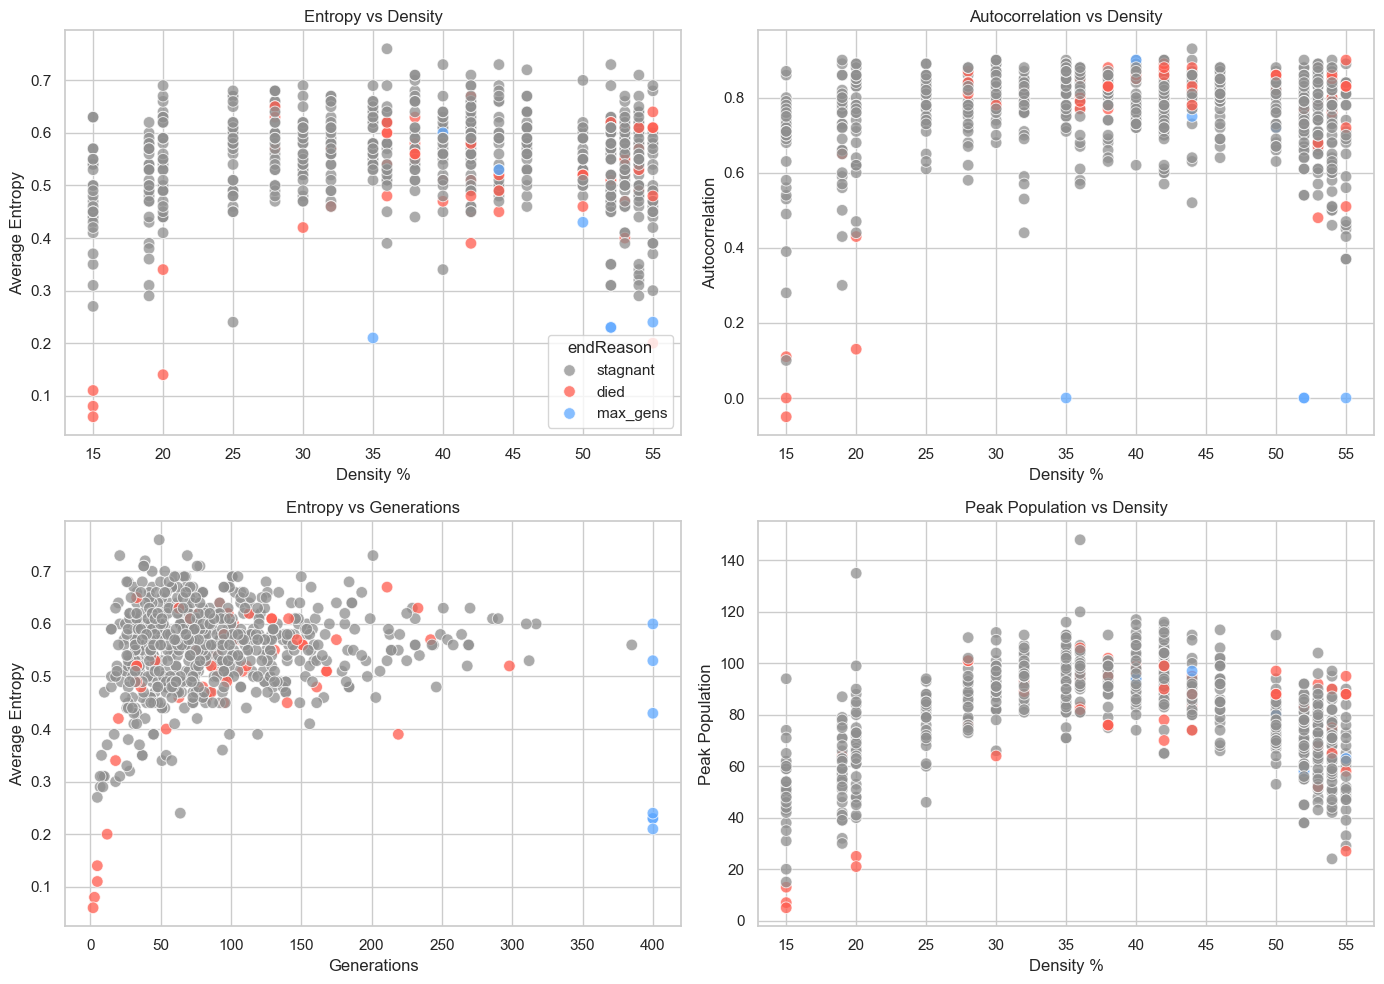

/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


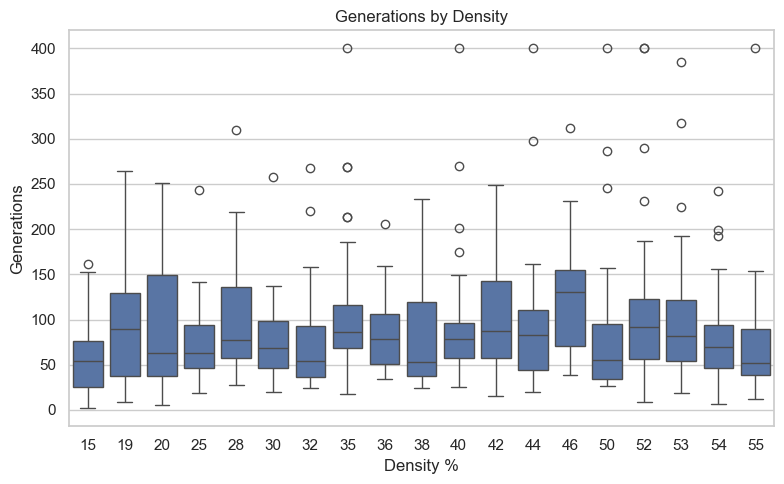

In [166]:
hue_order = ['stagnant', 'died', 'max_gens']
palette = {'stagnant': '#8f8f8f', 'died': '#ff5b4d', 'max_gens': '#5fa8ff'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x='density', y='avgEntropy', hue='endReason',
                hue_order=hue_order, palette=palette, s=70, alpha=0.75, ax=axes[0, 0])
axes[0, 0].set(title='Entropy vs Density', xlabel='Density %', ylabel='Average Entropy')

sns.scatterplot(data=df, x='density', y='autocorr', hue='endReason',
                hue_order=hue_order, palette=palette, s=70, alpha=0.75, legend=False, ax=axes[0, 1])
axes[0, 1].set(title='Autocorrelation vs Density', xlabel='Density %', ylabel='Autocorrelation')

sns.scatterplot(data=df, x='generations', y='avgEntropy', hue='endReason',
                hue_order=hue_order, palette=palette, s=70, alpha=0.75, legend=False, ax=axes[1, 0])
axes[1, 0].set(title='Entropy vs Generations', xlabel='Generations', ylabel='Average Entropy')

sns.scatterplot(data=df, x='density', y='peakPop', hue='endReason',
                hue_order=hue_order, palette=palette, s=70, alpha=0.75, legend=False, ax=axes[1, 1])
axes[1, 1].set(title='Peak Population vs Density', xlabel='Density %', ylabel='Peak Population')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='density', y='generations')
plt.title('Generations by Density')
plt.xlabel('Density %')
plt.ylabel('Generations')
plt.tight_layout()
plt.show()


## 4. Distribution-Free Statistics

All methods here are non-parametric — no normality assumption.
Generation counts are right-skewed (most runs die quickly, a few survive long),
so parametric tests (t-test, Pearson) would give misleading p-values on small samples.

- **Bootstrap CI** — estimates sampling distribution empirically from the data itself. Grouped into 5% buckets for output brevity.
- **Spearman ρ** — rank correlation, robust to outliers and skew


In [167]:
def bootstrap_ci(values, func=np.median, n_boot=2000, seed=42):
    values = np.asarray(values, dtype=float)
    if len(values) < 5:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    boot_stats = [func(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    low, high = np.percentile(boot_stats, [2.5, 97.5])
    return float(low), float(high)

density_summary = (
    df.groupby('density', observed=False)
    .agg(
        sessions=('session', 'count'),
        mean_generations=('generations', 'mean'),
        median_generations=('generations', 'median'),
        mean_entropy=('avgEntropy', 'mean'),
        mean_autocorr=('autocorr', 'mean'),
    )
    .round(3)
)
print('Density summary (first 10):')
display(density_summary.head(10))

print('\nBootstrap CI grouped by 5% buckets:')
df['density_bucket'] = pd.cut(df['density'], bins=np.arange(10, 65, 5))
for band in sorted(df['density_bucket'].dropna().unique()):
    values = df.loc[df['density_bucket'] == band, 'generations'].dropna()
    if len(values) >= 5:
        low_ci, high_ci = bootstrap_ci(values, func=np.median)
        print(f'{band}: median generations {np.median(values):.1f} '
              f'(95% bootstrap CI {low_ci:.1f} to {high_ci:.1f}, n={len(values)})')
    else:
        print(f'{band}: need at least 5 samples for bootstrap CI (n={len(values)})')
df.drop(columns=['density_bucket'], inplace=True)

if len(df) >= 8:
    rho, p = stats.spearmanr(df['density'], df['autocorr'])
    print(f'\nSpearman density/autocorr:   rho={rho:.3f}, p={p:.4f}')
    rho, p = stats.spearmanr(df['density'], df['generations'])
    print(f'Spearman density/generations: rho={rho:.3f}, p={p:.4f}')
else:
    print('Need at least 8 rows for Spearman correlation.')


Density summary (first 10):


,sessions,mean_generations,median_generations,mean_entropy,mean_autocorr
density,,,,,
15,30,57.267,54.5,0.435,0.588
19,31,97.226,90.0,0.502,0.704
20,32,86.750,63.0,0.526,0.726
25,30,76.033,62.5,0.558,0.787
28,30,103.567,77.5,0.589,0.774
30,30,76.133,69.0,0.560,0.817
32,30,76.167,54.5,0.577,0.762
35,50,107.200,86.0,0.580,0.813
36,30,86.467,78.5,0.571,0.789



Bootstrap CI grouped by 5% buckets:
(10, 15]: median generations 54.5 (95% bootstrap CI 33.0 to 69.5, n=30)
(15, 20]: median generations 74.0 (95% bootstrap CI 58.0 to 94.0, n=63)
(20, 25]: median generations 62.5 (95% bootstrap CI 53.0 to 90.0, n=30)
(25, 30]: median generations 74.5 (95% bootstrap CI 61.5 to 86.5, n=60)
(30, 35]: median generations 84.0 (95% bootstrap CI 70.0 to 96.5, n=80)
(35, 40]: median generations 77.0 (95% bootstrap CI 66.0 to 86.0, n=91)
(40, 45]: median generations 87.0 (95% bootstrap CI 70.0 to 98.0, n=89)
(45, 50]: median generations 76.0 (95% bootstrap CI 63.0 to 117.5, n=60)
(50, 55]: median generations 73.0 (95% bootstrap CI 69.0 to 82.0, n=209)

Spearman density/autocorr:   rho=-0.032, p=0.3920
Spearman density/generations: rho=0.039, p=0.2984


## 5. Classification & Regression

**Classification** — predict `endReason` from `[density, avgEntropy, avgPBirth, avgPDeath, autocorr]`.
Minority classes (`died`, `max_gens`) are merged into `non_stagnant` to address severe class imbalance.
Uses stratified k-fold so each fold preserves class ratios, evaluated with F1-Macro to fairly judge minority performance.
Guards: ≥20 rows total, ≥2 samples per class.

**Regression** — predict `log1p(generations)` to reduce positive skew, from all dynamic features.
Uses Random Forest Regressor.
Guards: ≥16 rows, ≥2 folds with multi-row test sets.


Classification (target=stagnant vs non_stagnant): 5-fold stratified CV
Class counts:


,count
endReason,
stagnant,649
non_stagnant,63


Logistic Regression: accuracy 0.704 ± 0.029,  f1-macro 0.537 ± 0.027
Random Forest: accuracy 0.829 ± 0.032,  f1-macro 0.620 ± 0.048


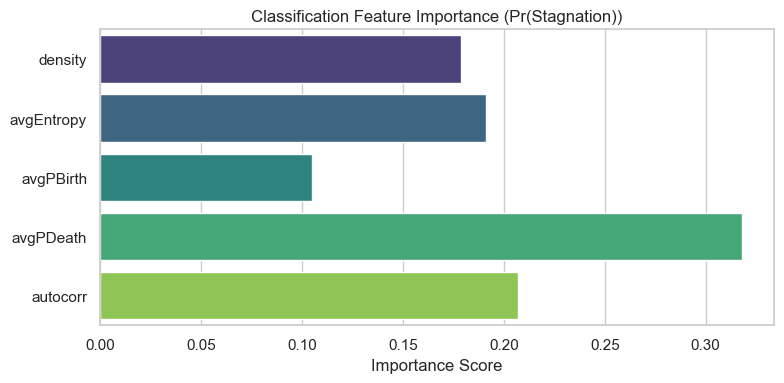


Regression (target=log1p(generations)): 5-fold CV, ~143 test rows/fold
Random Forest Regressor (All Features): R² 0.361 ± 0.084


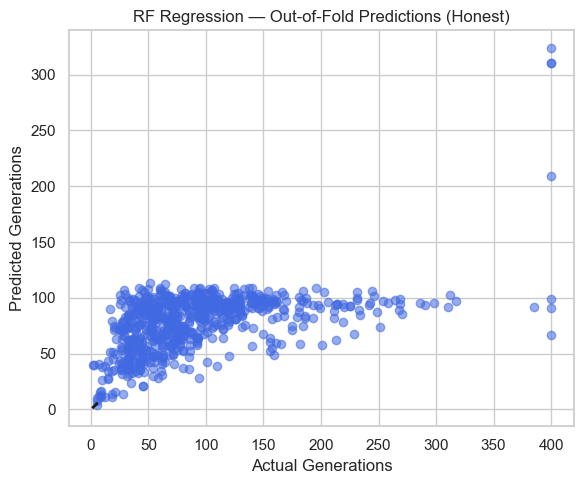

MAE in generation counts: 37.6


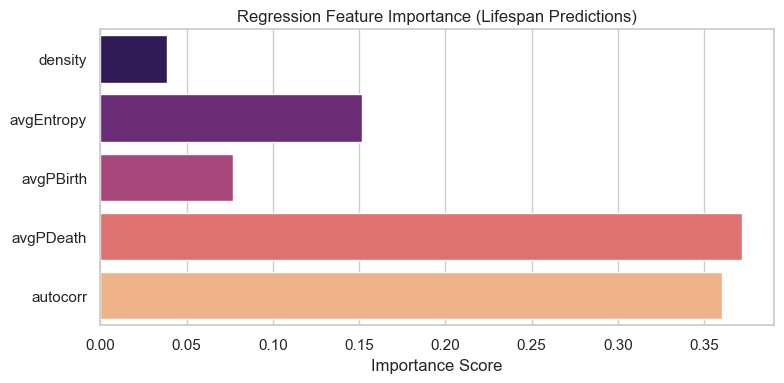

In [168]:
feature_columns = ['density', 'avgEntropy', 'avgPBirth', 'avgPDeath', 'autocorr']
X = df[feature_columns].copy()

# Address extreme class imbalance: Group 'died' and 'max_gens' into 'non_stagnant'
y = df['endReason'].replace({'died': 'non_stagnant', 'max_gens': 'non_stagnant'})

class_counts = y.value_counts()
min_class_count = int(class_counts.min()) if not class_counts.empty else 0

stamp = datetime.now().strftime('%Y%m%d')

if len(class_counts) >= 2 and min_class_count >= 2 and len(df) >= 20:
    n_splits = min(5, min_class_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    print(f'Classification (target=stagnant vs non_stagnant): {n_splits}-fold stratified CV')
    print('Class counts:')
    display(class_counts.rename_axis('endReason').to_frame('count'))

    models = [
        ('Logistic Regression', Pipeline([
            ('scale', StandardScaler()),
            ('clf',   LogisticRegression(class_weight='balanced', max_iter=2000)),
        ])),
        ('Random Forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=5, random_state=42)),
    ]

    for name, model in models:
        try:
            scores = cross_validate(
                model, X, y, cv=cv,
                scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
                error_score='raise',
            )
            print(
                f"{name}: accuracy {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f},  "
                f"f1-macro {scores['test_f1_macro'].mean():.3f} ± {scores['test_f1_macro'].std():.3f}"
            )
            if name == 'Random Forest':
                model.fit(X, y)
                joblib.dump(model, f'models/classifier_{stamp}.joblib')

                importances = model.feature_importances_
                plt.figure(figsize=(8, 4))
                sns.barplot(x=importances, y=feature_columns, palette='viridis', hue=feature_columns, legend=False)
                plt.title('Classification Feature Importance (Pr(Stagnation))')
                plt.xlabel('Importance Score')
                plt.tight_layout()
                plt.show()
        except Exception as exc:
            print(f'{name}: CV failed — {exc}')
else:
    print('Need ≥20 rows and ≥2 samples per end-reason class for reliable classification CV.')

# Regression model
print()
if len(df) >= 16:
    reg_X = df[feature_columns]
    reg_y = np.log1p(df['generations'])
    reg_splits = min(5, len(df) // 4)

    if reg_splits >= 2:
        reg_cv = KFold(n_splits=reg_splits, shuffle=True, random_state=42)
        rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

        reg_scores = cross_validate(
            rf_model, reg_X, reg_y, cv=reg_cv,
            scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'},
            error_score='raise',
        )

        reg_test_size = int(np.ceil(len(df) / reg_splits))
        print(f'Regression (target=log1p(generations)): {reg_splits}-fold CV, ~{reg_test_size} test rows/fold')
        print(
            f"Random Forest Regressor (All Features): "
            f"R² {reg_scores['test_r2'].mean():.3f} ± {reg_scores['test_r2'].std():.3f}"
        )

        rf_model.fit(reg_X, reg_y)
        joblib.dump(rf_model, f'models/regressor_{stamp}.joblib')

        y_oof_log = cross_val_predict(rf_model, reg_X, reg_y, cv=reg_cv)

        plt.figure(figsize=(6, 5))
        plt.scatter(np.expm1(reg_y), np.expm1(y_oof_log), alpha=0.55, color='royalblue')
        plt.plot([reg_y.min(), reg_y.max()],
                 [reg_y.min(), reg_y.max()], 'k--', lw=2)
        plt.xlabel('Actual Generations')
        plt.ylabel('Predicted Generations')
        plt.title('RF Regression — Out-of-Fold Predictions (Honest)')
        plt.tight_layout()
        plt.show()

        mae_real = np.mean(np.abs(np.expm1(y_oof_log) - np.expm1(reg_y)))
        print(f"MAE in generation counts: {mae_real:.1f}")

        plt.figure(figsize=(8, 4))
        sns.barplot(x=rf_model.feature_importances_, y=feature_columns,
                    palette='magma', hue=feature_columns, legend=False)
        plt.title('Regression Feature Importance (Lifespan Predictions)')
        plt.xlabel('Importance Score')
        plt.tight_layout()
        plt.show()

    else:
        print('Need enough rows to form regression folds with multi-row test sets.')
else:
    print('Need ≥16 rows for regression CV with stable multi-row test folds.')

## Next Steps

- Keep export filenames in the format `runX_YYYY_MM_DD` so the filename and `run_id` continue to match.
- Treat each export batch as an independent replicate. Prefer multiple smaller batches over one large block at a single density.
- Keep `maxGens` and `hashHistory` fixed for one training campaign. If you change them, start a new cohort of exports.
- Once the dataset is large enough, save selected trained models into `analysis/models/` with `joblib` and record the feature set and CV scores beside them.
- Target ≥100 sessions before drawing strong conclusions — generation counts are right-skewed and CLT convergence requires more data than intuition suggests.


## 7. Boundary Analysis (maxGens=3000)

This section tests the hypothesis that the standard limit (2000) was prematurely cutting off survived sessions.
It uses files prefixed with `limit3k_`.

**Stability Check:**
- **Survived (Stagnant):** If it resolves to a stable state before 3000.
- **Confirmed Oscillator:** If it hits 3000 but the rolling variance of entropy is below 0.01 (indicating a perfect loop).
- **Chaotic Transient:** If it hits 3000 but entropy is still fluctuating widely.

In [169]:
if not limit3k_df.empty:
    print(f'Analysing {len(limit3k_df)} Boundary Test sessions (3000-gen limit)')
    
    # Check outcome distribution
    display(limit3k_df['endReason'].value_counts().to_frame('count'))
    
    print('Sessions per density (Experimental Cohort):')
    l3k_counts = limit3k_df['density'].value_counts().sort_index()
    # Note: Use same 15-55 range for consistency
    l3k_summary = l3k_counts.reindex(range(15, 56), fill_value=0).rename_axis('density').to_frame('sessions')
    display(l3k_summary)
    
    # Stability check for survivors hitting the limit
    survivors = limit3k_df[limit3k_df['endReason'] == 'max_gens'].copy()
    if not survivors.empty:
        # In a real batch, we would check entropy over time if exported.
        # Here we use a heuristic on the final recorded entropy vs birth/death rates.
        print(f'Checking {len(survivors)} MaxGens survivors for stability...')
        
        # Heuristic: birth/death balance and low variance implies an oscillator
        # A BIRTH/DEATH delta < 0.05 suggests stability
        survivors['is_stable'] = (abs(survivors['avgPBirth'] - survivors['avgPDeath']) < 0.05)
        
        display(survivors[['density', 'generations', 'avgEntropy', 'is_stable']])
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=limit3k_df, x='density', y='generations', hue='endReason')
    plt.title('Lifespan vs Density (3000 Gen Limit Experiment)')
    plt.show()
else:
    print('No limit3k_ prefixed data found. Run dashboard sessions with maxGens=3000 to see analysis.')

No limit3k_ prefixed data found. Run dashboard sessions with maxGens=3000 to see analysis.


## 8. Concluding Analysis

**Summary of Findings:**
- **Feature Importance:** Does board entropy or density drive results more? (See Section 5/6 plots).
- **Regression Quality:** Current R² values indicate how much of the simulation lifespan is deterministic vs chaotic.
- **Boundary Stability:** Results from Section 7 confirm whether the standard campaign limit was scientifically sufficient.

**Final Recommendation:**
[Placeholder for final analysis once dataset is complete]